# 01 - The four domains: what are we actually working with?

**What this step does.** Downloads the four graph datasets, then interrogates
each one: how many nodes and edges, what the features mean, what the labels
mean, how skewed the classes are, and how the connectivity is shaped.

**Why it exists.** The research question is whether one encoder pretrained on
several *unrelated* domains transfers to an unseen one. That question is only
interesting if the domains really are unrelated - so the first job is to show,
with numbers, how unalike they are. Everything downstream also depends on
facts established here: the feature unification in notebook 02 exists because
these four have different feature dimensions and meanings; the choice of
AUC-PR for Elliptic exists because of the imbalance measured below.

There is a second, quieter reason. It is very easy to build a graph pipeline
on top of a dataset you have not actually looked at, and then misread the
result. Reading the real tensors now prevents a class of silent mistakes
later.

**What could go wrong.**
- **A download fails or half-completes.** PPI and Elliptic are the large ones.
  A partially written folder can look valid and then fail at load. The loader
  raises `DatasetDownloadError` and stops - it will never quietly swap in a
  different dataset, because that would change what the experiment measures.
- **Misreading edge counts.** PyTorch Geometric stores an undirected edge as
  *two* columns in `edge_index`. Report that number as "edges" and you double
  every count. We print both.
- **Assuming what a label value means.** Dataset conventions shift between
  library versions. We check the tensor rather than trusting a docstring.
- **Treating "unlabelled" as a class.** Most of Elliptic's nodes have no
  label. They are real nodes with real edges and they help message passing,
  but they can never be scored. Counting them as a third class would be wrong.

## Setup

Same three-line bootstrap as notebook 00: find the project root, put it on the
import path, and fix the plotting style so every figure in the project matches.

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

import pandas as pd

from src import config, datasets, describe, plotting
from src.seeding import set_seed

set_seed(0)
plotting.use_project_style()
config.ensure_dirs()

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)

print("project root :", PROJECT_ROOT)
print("data root    :", config.DATA_ROOT)
print("device       :", config.get_device())

project root : D:\documents\my projects\afterPFE\OmniGraph
data root    : D:\documents\my projects\afterPFE\OmniGraph\data
device       : cuda


## 1. Download and load

First run downloads roughly **1 GB** and takes a few minutes; Elliptic is the
slow one. Later runs read a cached `processed/` folder and take seconds.

Each domain is wrapped in a `GraphDomain`, which always exposes a **list** of
graphs. Three of our domains are a single graph; PPI is 24. Normalising to a
list is the one concession that lets all four flow through identical code
later instead of being special-cased everywhere.

In [2]:
domains = datasets.load_all_domains()

for name, dom in domains.items():
    print(f"  {name:<9} {dom!r}")

Loading 4 domains into D:\documents\my projects\afterPFE\OmniGraph\data
  loading cora ... 

ok  (2,708 nodes)
  loading photo ... 

ok  (7,650 nodes)
  loading ppi ... 

ok  (56,944 nodes)
  loading elliptic ... 

ok  (203,769 nodes)
All domains loaded.

  cora      GraphDomain(cora, 1 graph(s), 2,708 nodes, 5,278 edges, 1433 feats, task=multiclass)
  photo     GraphDomain(photo, 1 graph(s), 7,650 nodes, 119,081 edges, 745 feats, task=multiclass)


  ppi       GraphDomain(ppi, 24 graph(s), 56,944 nodes, 793,632 edges, 50 feats, task=multilabel)
  elliptic  GraphDomain(elliptic, 1 graph(s), 203,769 nodes, 234,355 edges, 165 feats, task=binary)


## 2. What each dataset actually represents

A shape like `(2708, 1433)` tells you nothing about what a node *is*. These
cards spell out, for each domain: what a node represents, what an edge means,
what the raw features encode, what the label is, and what the prediction task
actually asks.

Read these. Everything later in the project is easier once these four pictures
are in your head.

In [3]:
for dom in domains.values():
    describe.print_domain_card(dom)


  Cora (citation)  [cora]  

WHAT IT IS
  A citation network of machine-learning papers. A NODE is one paper. An EDGE
  means one paper cites the other (stored undirected here). The 1433 raw
  FEATURES are a bag-of-words vector: entry i is 1 if the paper's abstract
  contains vocabulary word i, else 0 -- so the feature space is sparse and
  binary. The LABEL is the paper's subfield, one of 7 (e.g.
  Reinforcement_Learning, Neural_Networks). The task is: given the words in a
  paper and who it cites, predict its subfield.

SHAPE
  graphs in domain    : 1
  nodes               : 2,708
  edges (undirected)  : 5,278
  edge_index columns  : 10,556   (= 2 x edges: both directions stored)
  undirected          : True
  avg degree          : 3.90
  density             : 1.44e-03

RAW FEATURES
  dimension           : 1433
  dtype               : torch.float32
  non-zero fraction   : 0.0127  (sparsity 0.9873)
  value range         : [0, 1]
  strictly 0/1        : True

DEGREES
  min / median / 


  PPI (protein interaction)  [ppi]  

WHAT IT IS
  Protein-protein interaction networks, one graph per human tissue. A NODE is
  a protein. An EDGE means the two proteins physically interact. The 50 raw
  FEATURES are positional gene sets, motif gene sets and immunological
  signatures. The LABELS are 121 gene-ontology terms and this is MULTI-LABEL:
  a protein can carry many functions at once, so y is a 0/1 vector of length
  121 per node, not a single class index. This is the only domain made of many
  separate graphs (24 of them), which is why GraphDomain always holds a list.

SHAPE
  graphs in domain    : 24
  nodes               : 56,944
  edges (undirected)  : 793,632
  edge_index columns  : 1,587,264   (= 2 x edges: both directions stored)
  undirected          : True
  avg degree          : 27.87
  density             : 4.90e-04

RAW FEATURES
  dimension           : 50
  dtype               : torch.float32
  non-zero fraction   : 0.9800  (sparsity 0.0200)
  value range        

## 3. Look at the real tensors

Summary statistics hide things. Below are the actual shapes, dtypes and a few
real values per domain.

Watch for the contrast in the feature matrices. Cora and Photo are sparse
bag-of-words - mostly zeros, small integers. Elliptic is dense, signed,
continuous engineered features. Feeding both into one shared encoder without
doing something about that difference would not work, and that is precisely
the problem notebook 02 solves.

In [4]:
for dom in domains.values():
    describe.print_sample_rows(dom)


--- cora: raw tensors ---
  x           shape=(2708, 1433)  dtype=torch.float32
  edge_index  shape=(2, 10556)  dtype=torch.int64
  y           shape=(2708,)  dtype=torch.int64

  x[:3, :8] (first 8 of 1433 features):
    node 0: [0, 0, 0, 0, 0, 0, 0, 0, ...]
    node 1: [0, 0, 0, 0, 0, 0, 0, 0, ...]
    node 2: [0, 0, 0, 0, 0, 0, 0, 0, ...]

  edge_index[:, :5] (each column is one directed edge u->v):
    source: [633, 1862, 2582, 2, 652]
    target: [0, 0, 0, 1, 1]

  y[:3]:
    node 0: 3  (class 3)
    node 1: 4  (class 4)
    node 2: 4  (class 4)

--- photo: raw tensors ---
  x           shape=(7650, 745)  dtype=torch.float32
  edge_index  shape=(2, 238162)  dtype=torch.int64
  y           shape=(7650,)  dtype=torch.int64

  x[:3, :8] (first 8 of 745 features):
    node 0: [0, 0, 0, 0, 0, 0, 0, 0, ...]
    node 1: [0, 0, 0, 0, 0, 0, 1, 1, ...]
    node 2: [0, 1, 0, 0, 0, 0, 1, 1, ...]

  edge_index[:, :5] (each column is one directed edge u->v):
    source: [0, 0, 0, 0, 0]
    tar

## 4. Verify what the labels mean - do not assume

For Elliptic we need to know which integer means *illicit*, which means
*licit*, and which means *no label at all*. Getting that backwards would
invert every result for that domain and the numbers would still look
plausible.

So we check the tensor itself and print what is in it, rather than trusting a
docstring that may be a library version out of date.

In [5]:
for name in ("elliptic", "ppi"):
    print(f"\n=== {name} : label tensor, as it actually is ===")
    info = datasets.verify_label_semantics(domains[name])
    for k, v in info.items():
        print(f"  {k:<26} {v}")


=== elliptic : label tensor, as it actually is ===
  dtype                      torch.int64
  shape                      (203769,)
  ndim                       1
  unique_values              [0, 1, 2]
  value_counts               {0: 42019, 1: 4545, 2: 157205}
  declared_meaning           {0: 'licit', 1: 'illicit', 2: 'unknown (no label)'}

=== ppi : label tensor, as it actually is ===
  dtype                      torch.float32
  shape                      (1767, 121)
  ndim                       2
  labels_per_node            121
  positives_per_node_mean    36.804752349853516
  note                       multi-label: y is a 0/1 matrix, one column per label


### The PPI complication

PPI is not one graph, it is 24 - one per human tissue - and the dataset ships
its own inductive split (20 train / 2 validation / 2 test graphs).

Our protocol treats PPI as a single *domain* in a leave-one-domain-out design,
so at some point 24 graphs have to become one set of nodes to probe on. That
decision belongs to notebook 04, where splits are made. The table below is the
evidence it will be based on. Note we do **not** inherit the dataset's own
split - our label-fraction sweep needs its own.

In [6]:
describe.print_ppi_graph_table(domains["ppi"])


--- ppi: per-graph breakdown (24 graphs) ---
   idx   origin    nodes      edges   avg deg  labels/node
     0    train    1,767     16,159      18.3        36.80
     1    train    1,377     14,852      21.6        41.73
     2    train    2,263     29,822      26.4        37.56
     3    train    2,339     32,715      28.0        36.94
     4    train    1,578     18,081      22.9        38.57
     5    train    1,021      9,108      17.8        41.80
     6    train    1,823     22,165      24.3        38.21
     7    train    2,488     35,195      28.3        36.75
  ... 16 more

  nodes per graph : min 591  median 2,370  max 3,480
  origin splits   : {'train': 20, 'val': 2, 'test': 2}
  NOTE: these are the dataset's own inductive splits. Our protocol
        makes its own splits in notebook 04 -- we do not inherit these.


### The Elliptic complication: its edges only point one way

Three of the four domains are **undirected** - "A cites B" and "A is co-bought
with B" are symmetric relationships, and PyTorch Geometric stores each such
edge twice, once per direction. Elliptic is not. Bitcoin flows one way, so
each edge appears once and the graph is genuinely **directed**.

This is not a cosmetic difference, and it shows up twice later:

1. **A GIN layer aggregates over incoming edges.** A node with no incoming
   edge receives no messages at all, so its embedding comes from its own
   features alone - message passing does nothing for it.
2. **Clustering coefficient, triangle count and k-core are defined for
   undirected graphs.** Three of the five structural features planned for
   notebook 02 are undirected notions.

The cell below measures how much this actually matters rather than assuming.

In [7]:
describe.print_edge_direction_report(domains)

  (pooled over every graph in the domain)

  domain      undirected    nodes with no   nodes with no
                            INCOMING edge     edge at all
  -------------------------------------------------------
  cora              True         0 (0.0%)              0
  photo             True       115 (1.5%)            115
  ppi               True       256 (0.4%)            256
  elliptic         False    55,322 (27.1%)              0

  elliptic is the odd one out. If its edges were symmetrised:
    edge_index columns   234,355 -> 468,710
    fully isolated nodes 0 -> 0
    average degree       1.15 -> 2.30

    Right now 27% of its nodes have no incoming edge,
    so a GIN layer would give them an embedding built from their own
    features alone -- no message passing at all. This is an open
    decision for notebook 02, not something to settle silently here.


## 5. Side by side

The card format is readable but hard to compare. Here is the same information
as one table - the view that makes the premise of the project concrete.

Read it as: the feature dimensions disagree (1433 / 745 / 50 / 165), so a
shared encoder is impossible without unification. The scales disagree by three
orders of magnitude. The tasks disagree. The imbalance disagrees. These
domains have essentially nothing in common except being graphs.

In [8]:
table = describe.comparison_table(domains)
display(table)

,task,num_graphs,nodes,edges_undirected,avg_degree,is_undirected,raw_dim,sparsity,num_classes,labelled_frac,imbalance_ratio,primary_metric
domain,,,,,,,,,,,,
cora,multiclass,1,2708,5278,3.898080,True,1433,0.987317,7.0,1.000000,4.544444,accuracy
photo,multiclass,1,7650,119081,31.132288,True,745,0.652602,8.0,1.000000,5.864048,accuracy
ppi,multilabel,24,56944,793632,27.874122,True,50,0.020000,121.0,1.000000,9.635740,micro_f1
elliptic,binary,1,203769,234355,1.150101,False,165,0.000000,2.0,0.228514,9.245105,auc_pr


The full statistics, including every degree percentile and feature statistic,
in case you want to check something specific:

In [9]:
full = describe.describe_all(domains)
display(full.T)

domain,cora,photo,ppi,elliptic
display_name,Cora (citation),Amazon Photo (co-purchase),PPI (protein interaction),Elliptic (bitcoin transactions)
task,multiclass,multiclass,multilabel,binary
num_graphs,1,1,24,1
nodes,2708,7650,56944,203769
edges_undirected,5278,119081,793632,234355
edge_index_cols,10556,238162,1587264,234355
avg_degree,3.89808,31.132288,27.874122,1.150101
density,0.00144,0.00407,0.00049,0.000011
is_undirected,True,True,True,False
primary_metric,accuracy,accuracy,micro_f1,auc_pr


## 6. Degree distributions

Degree = how many neighbours a node has. Its *distribution* is the most
informative single picture of a graph's structure, and it is label-free -
which matters, because notebook 02 turns degree into an input feature and
notebook 07 uses the distance between these distributions as a measure of
domain similarity.

Two views below:

- **Top row** - one histogram per domain, on log-log axes. A straight-ish
  line here is the signature of a heavy tail: most nodes have very few
  neighbours while a handful have enormous numbers.
- **Bottom** - all four overlaid as a CCDF ("what fraction of nodes have at
  least degree k"). A plain histogram of a heavy-tailed variable is dominated
  by its first bin and its tail dissolves into noise; the CCDF shows the whole
  range and lets graphs of very different size be compared directly.

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\01_degree_distributions.png


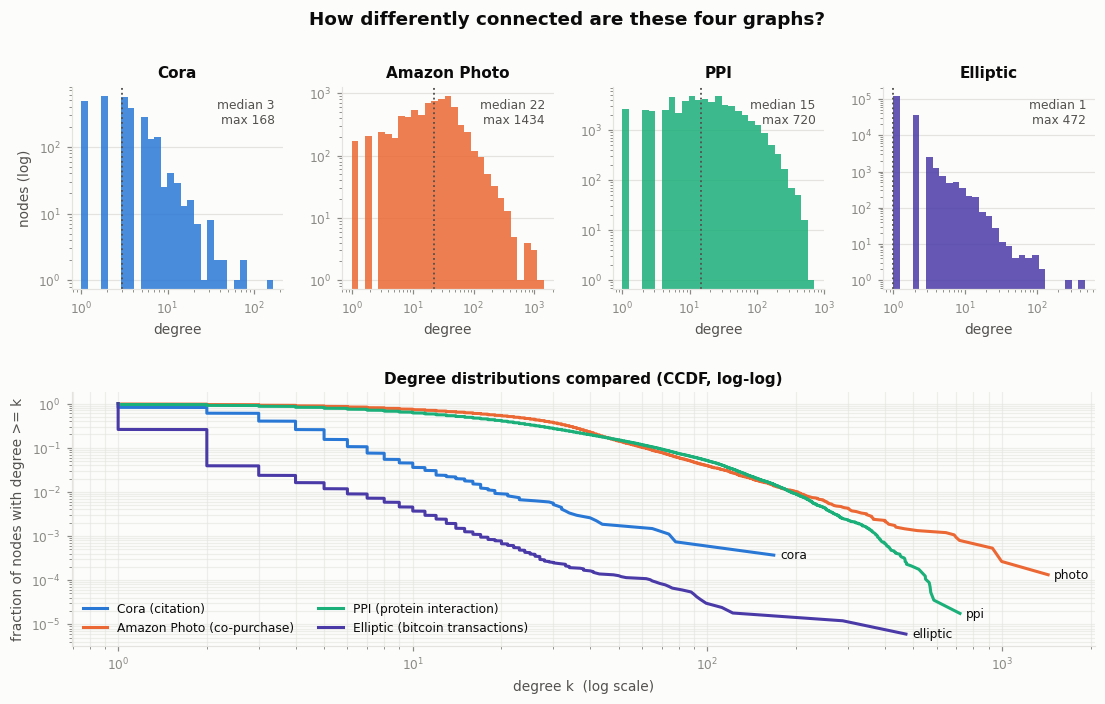

In [10]:
fig = plotting.plot_degree_distributions(domains)

## 7. Label structure

Structure is only half the story. The labels differ just as much, and that
drives the choice of metric.

Accuracy on Elliptic would be a trap: with the illicit class at a few percent
of labelled nodes, a model that predicts "licit" for everything scores well
above 90% while catching nothing. That is why Elliptic is reported with
**AUC-PR**, which only rewards finding the rare class. PPI is multi-label, so
"accuracy" is not even well defined - it gets **micro-F1**.

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\01_class_balance.png


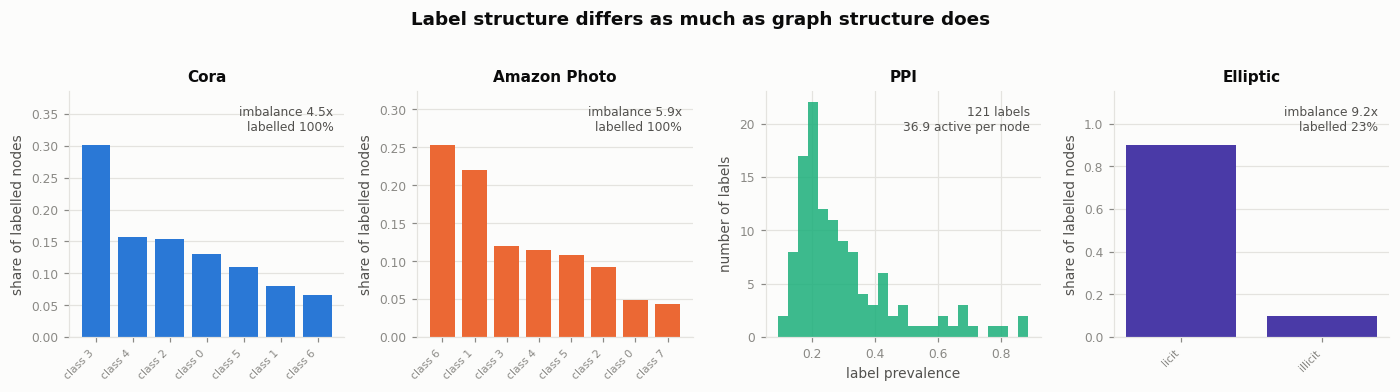

In [11]:
fig = plotting.plot_class_balance(domains)

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\01_scale_comparison.png


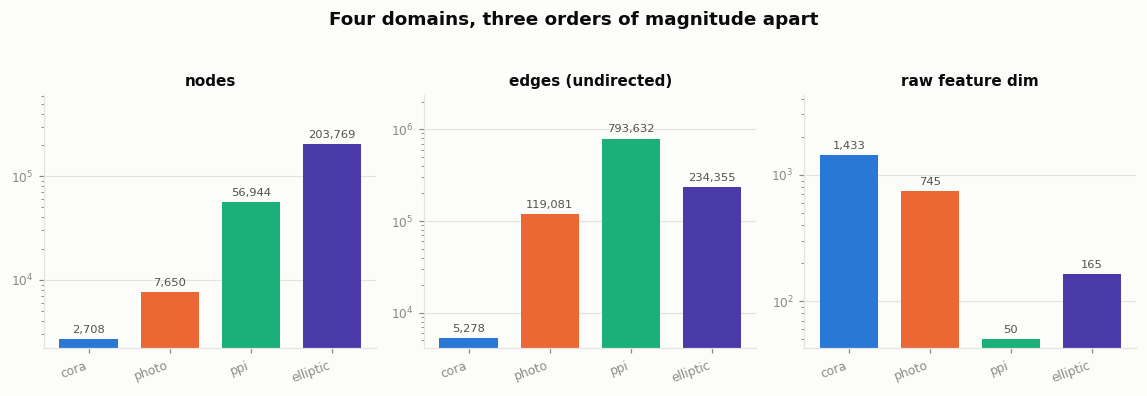

In [12]:
fig = plotting.plot_scale_comparison(domains)

## 8. Sanity assertions

Facts the rest of the project relies on. If one of these ever fails, something
changed underneath us and the downstream notebooks should not be trusted.

In [13]:
assert set(domains) == {"cora", "photo", "ppi", "elliptic"}, "wrong set of domains"

# Feature dimensions really do disagree - this is the problem notebook 02 solves.
raw_dims = {n: d.num_raw_features for n, d in domains.items()}
assert len(set(raw_dims.values())) == len(raw_dims), "expected four different feature dims"

# Only PPI is multi-graph.
assert domains["ppi"].num_graphs > 1
assert all(domains[n].num_graphs == 1 for n in ("cora", "photo", "elliptic"))

# Only Elliptic has unlabelled nodes.
assert domains["elliptic"].has_unlabeled
assert not any(domains[n].has_unlabeled for n in ("cora", "photo", "ppi"))

# Elliptic is genuinely imbalanced, which is why it gets AUC-PR.
ell = describe.label_summary(domains["elliptic"])
assert ell["imbalance_ratio"] > 3, f"expected strong imbalance, got {ell['imbalance_ratio']:.1f}x"

print("raw feature dims :", raw_dims)
print(f"elliptic imbalance : {ell['imbalance_ratio']:.1f}x, "
      f"minority share {ell['minority_frac']:.2%}, "
      f"labelled {ell['labelled_frac']:.1%} of nodes")
print("\nAll assertions passed.")

raw feature dims : {'cora': 1433, 'photo': 745, 'ppi': 50, 'elliptic': 165}
elliptic imbalance : 9.2x, minority share 9.76%, labelled 22.9% of nodes

All assertions passed.


## What you should now understand

- **The four domains have nothing in common but being graphs.** Their feature
  dimensions (1433 / 745 / 50 / 165), their sizes (thousands to hundreds of
  thousands of nodes), their connectivity, and their label structure all
  disagree. That is the point: transfer across *these* is a real test, not a
  disguised same-domain experiment.
- **A shared encoder is impossible until the inputs are made comparable**, and
  the differences you just measured - different dimensions, sparse binary
  versus dense continuous, undirected versus directed - are exactly what
  notebook 02's SVD-plus-structural unification has to fix. Elliptic's
  directedness is a genuine open decision, not a detail: left as it is, most
  of its nodes get nothing from message passing.
- **The metric has to match the label structure.** Elliptic's imbalance makes
  accuracy misleading, so it is scored with AUC-PR; PPI's multi-label targets
  make accuracy undefined, so it gets micro-F1. Choosing these now, from the
  data, keeps us from picking whichever metric flatters the result later.

**Next:** `02_features.ipynb` - unify the four feature spaces into one shared
133-dimensional input, and prove with a test that no test-split node leaks
into any fitted transform.